In [1]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)

# Load & clean (same as Phase 1)
df = pd.read_csv('Sample - Superstore.csv', encoding='windows-1252')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])
df.drop_duplicates(inplace=True)
df['Year']      = df['Order Date'].dt.year
df['Month']     = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

print("✅ Data loaded. Shape:", df.shape)

Saving Sample - Superstore.csv to Sample - Superstore.csv
✅ Data loaded. Shape: (9994, 24)


In [2]:
# Aggregate to monthly sales
monthly_sales = (
    df.groupby('YearMonth')['Sales']
    .sum()
    .reset_index()
)
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()
monthly_sales.columns = ['ds', 'y']   # Prophet-friendly naming from the start

monthly_sales = monthly_sales.sort_values('ds').reset_index(drop=True)

print("Monthly series shape:", monthly_sales.shape)
print(monthly_sales.head(6))

Monthly series shape: (48, 2)
          ds           y
0 2014-01-01  14236.8950
1 2014-02-01   4519.8920
2 2014-03-01  55691.0090
3 2014-04-01  28295.3450
4 2014-05-01  23648.2870
5 2014-06-01  34595.1276


In [3]:
monthly_sales['lag_1']  = monthly_sales['y'].shift(1)   # last month
monthly_sales['lag_2']  = monthly_sales['y'].shift(2)   # 2 months ago
monthly_sales['lag_3']  = monthly_sales['y'].shift(3)   # 3 months ago
monthly_sales['lag_12'] = monthly_sales['y'].shift(12)  # same month last year

print("✅ Lag features added")
monthly_sales[['ds','y','lag_1','lag_12']].head(15)

✅ Lag features added


,ds,y,lag_1,lag_12
0,2014-01-01,14236.8950,NaN,NaN
1,2014-02-01,4519.8920,14236.8950,NaN
2,2014-03-01,55691.0090,4519.8920,NaN
3,2014-04-01,28295.3450,55691.0090,NaN
4,2014-05-01,23648.2870,28295.3450,NaN
5,2014-06-01,34595.1276,23648.2870,NaN
6,2014-07-01,33946.3930,34595.1276,NaN
7,2014-08-01,27909.4685,33946.3930,NaN
8,2014-09-01,81777.3508,27909.4685,NaN
9,2014-10-01,31453.3930,81777.3508,NaN


In [4]:
monthly_sales['rolling_3']  = monthly_sales['y'].shift(1).rolling(window=3).mean()   # 3-month avg
monthly_sales['rolling_6']  = monthly_sales['y'].shift(1).rolling(window=6).mean()   # 6-month avg
monthly_sales['rolling_12'] = monthly_sales['y'].shift(1).rolling(window=12).mean()  # 12-month avg

print("✅ Rolling features added")
monthly_sales[['ds','y','rolling_3','rolling_6','rolling_12']].head(16)

✅ Rolling features added


,ds,y,rolling_3,rolling_6,rolling_12
0,2014-01-01,14236.8950,NaN,NaN,NaN
1,2014-02-01,4519.8920,NaN,NaN,NaN
2,2014-03-01,55691.0090,NaN,NaN,NaN
3,2014-04-01,28295.3450,24815.932000,NaN,NaN
4,2014-05-01,23648.2870,29502.082000,NaN,NaN
5,2014-06-01,34595.1276,35878.213667,NaN,NaN
6,2014-07-01,33946.3930,28846.253200,26831.092600,NaN
7,2014-08-01,27909.4685,30729.935867,30116.008933,NaN
8,2014-09-01,81777.3508,32150.329700,34014.271683,NaN
9,2014-10-01,31453.3930,47877.737433,38361.995317,NaN


In [5]:
monthly_sales['month_num']  = monthly_sales['ds'].dt.month
monthly_sales['quarter']    = monthly_sales['ds'].dt.quarter
monthly_sales['year']       = monthly_sales['ds'].dt.year

# Is it Q4? (Oct–Dec = historically high sales)
monthly_sales['is_q4'] = (monthly_sales['quarter'] == 4).astype(int)

print("✅ Calendar features added")
monthly_sales.head(5)

✅ Calendar features added


,ds,y,lag_1,lag_2,lag_3,lag_12,rolling_3,rolling_6,rolling_12,month_num,quarter,year,is_q4
0,2014-01-01,14236.895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,2014,0
1,2014-02-01,4519.892,14236.895,NaN,NaN,NaN,NaN,NaN,NaN,2,1,2014,0
2,2014-03-01,55691.009,4519.892,14236.895,NaN,NaN,NaN,NaN,NaN,3,1,2014,0
3,2014-04-01,28295.345,55691.009,4519.892,14236.895,NaN,24815.932,NaN,NaN,4,2,2014,0
4,2014-05-01,23648.287,28295.345,55691.009,4519.892,NaN,29502.082,NaN,NaN,5,2,2014,0


In [6]:
print("Nulls per column:")
print(monthly_sales.isnull().sum())
print("\nTotal rows:", len(monthly_sales))

Nulls per column:
ds             0
y              0
lag_1          1
lag_2          2
lag_3          3
lag_12        12
rolling_3      3
rolling_6      6
rolling_12    12
month_num      0
quarter        0
year           0
is_q4          0
dtype: int64

Total rows: 48


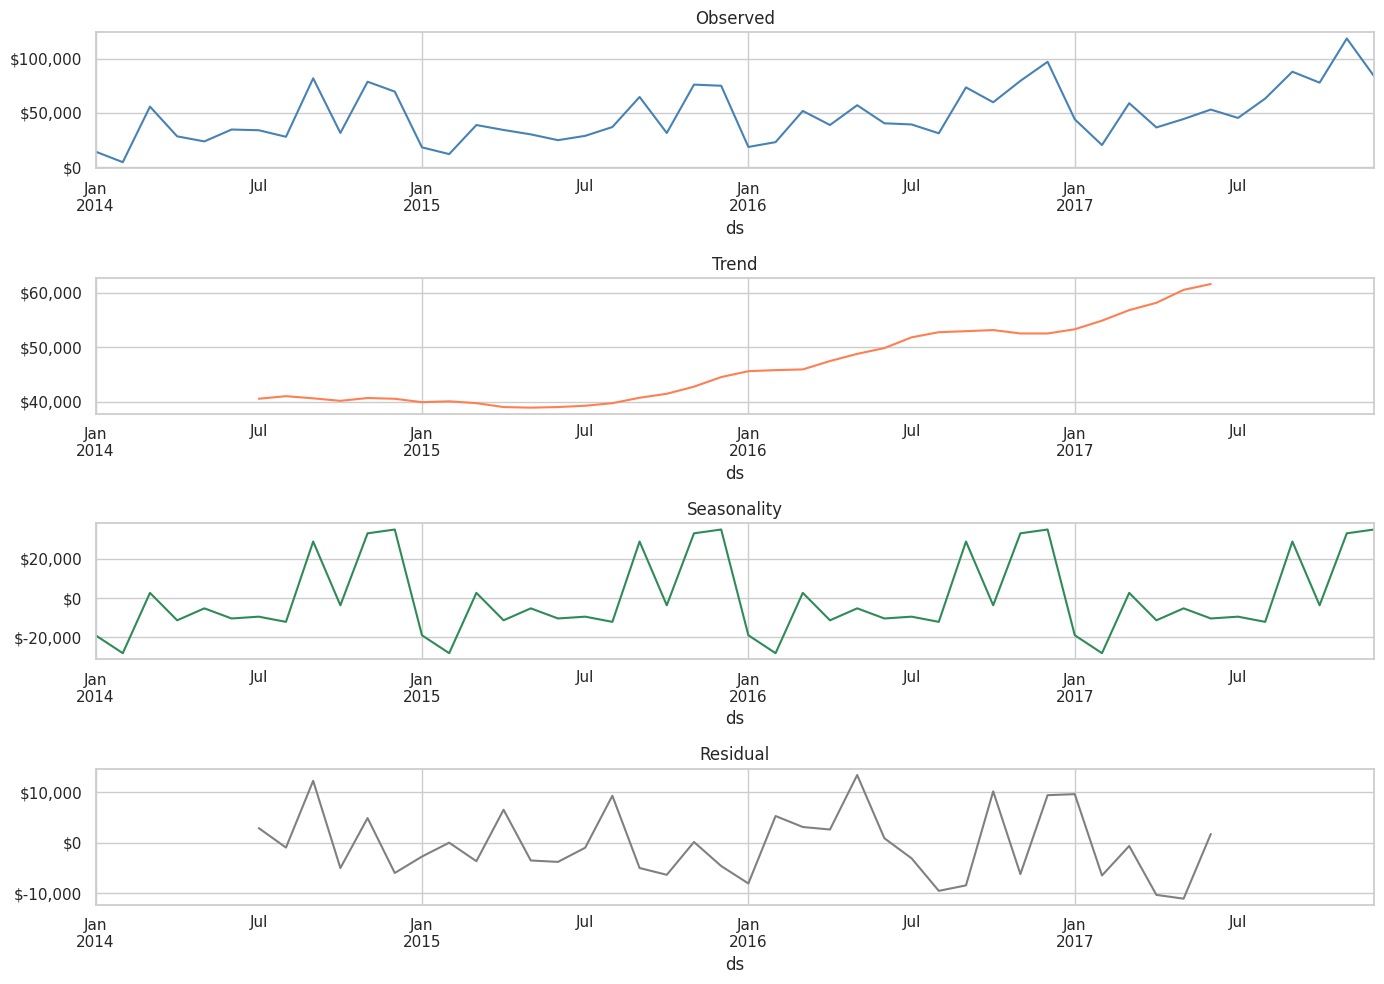

✅ Saved: time_series_decomposition.png


In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set date as index for decomposition
ts = monthly_sales.set_index('ds')['y']

decomposition = seasonal_decompose(ts, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomposition.observed.plot(ax=axes[0],  title='Observed',   color='steelblue')
decomposition.trend.plot(ax=axes[1],     title='Trend',      color='coral')
decomposition.seasonal.plot(ax=axes[2],  title='Seasonality',color='seagreen')
decomposition.resid.plot(ax=axes[3],     title='Residual',   color='gray')

for ax in axes:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('time_series_decomposition.png', dpi=150)
plt.show()
print("✅ Saved: time_series_decomposition.png")

In [8]:
# Drop rows with NaN (first 12 rows due to lag_12)
monthly_clean = monthly_sales.dropna().reset_index(drop=True)

# Split: last 6 months = test
split_index = len(monthly_clean) - 6

train = monthly_clean.iloc[:split_index].copy()
test  = monthly_clean.iloc[split_index:].copy()

print(f"Train: {len(train)} months  ({train['ds'].min().date()} → {train['ds'].max().date()})")
print(f"Test : {len(test)} months   ({test['ds'].min().date()} → {test['ds'].max().date()})")

Train: 30 months  (2015-01-01 → 2017-06-01)
Test : 6 months   (2017-07-01 → 2017-12-01)


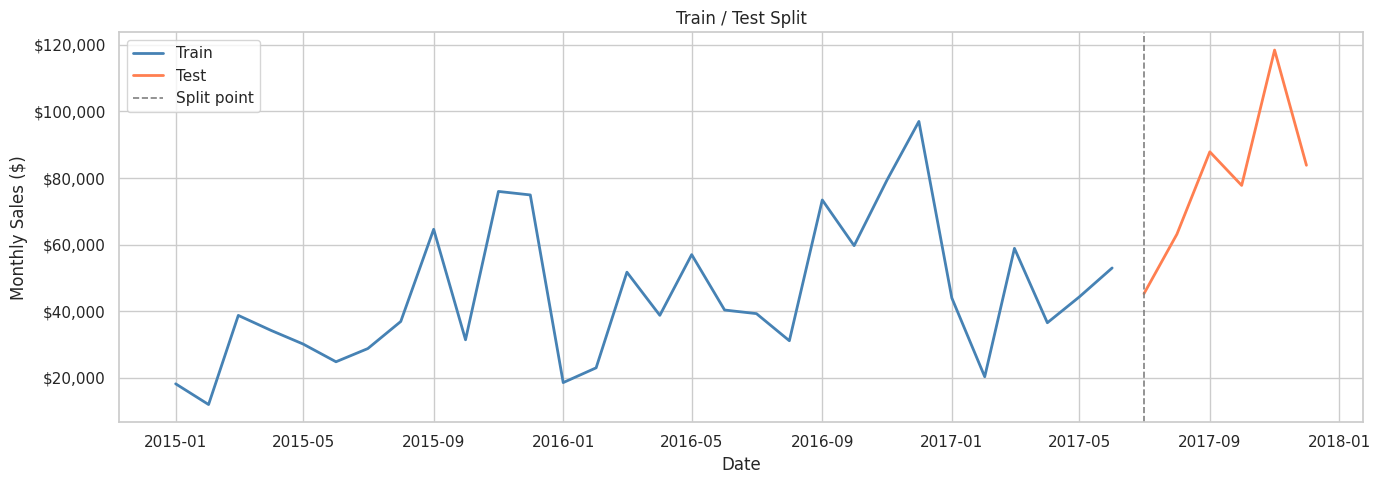

✅ Saved: train_test_split.png


In [9]:
plt.figure(figsize=(14, 5))
plt.plot(train['ds'], train['y'], label='Train', color='steelblue', linewidth=2)
plt.plot(test['ds'],  test['y'],  label='Test',  color='coral',     linewidth=2)
plt.axvline(test['ds'].iloc[0], color='gray', linestyle='--', linewidth=1.2, label='Split point')
plt.title('Train / Test Split')
plt.xlabel('Date')
plt.ylabel('Monthly Sales ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.legend()
plt.tight_layout()
plt.savefig('train_test_split.png', dpi=150)
plt.show()
print("✅ Saved: train_test_split.png")

In [10]:
monthly_clean.to_csv('monthly_sales_features.csv', index=False)
print("✅ Saved: monthly_sales_features.csv")
print("Columns saved:", monthly_clean.columns.tolist())

✅ Saved: monthly_sales_features.csv
Columns saved: ['ds', 'y', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_3', 'rolling_6', 'rolling_12', 'month_num', 'quarter', 'year', 'is_q4']
